In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

In [2]:
# the input and output files of the simulation for cross-referencing
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
# sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/rad_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch.h5'

In [3]:
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    fM = simf['meta']
    print(fT.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]"
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]"
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]"
...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]"
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]"
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]"
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,pixel tpc,pixel x,pixel y,trig z,trig t,waveform,attribution,label
0,0,0,-1067.25,-575.25,929.386963,5804.554199,"[40.82821273803711, 46.014671325683594, -53.52...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
1,0,0,-1066.75,-575.25,929.386963,5804.554199,"[-49.808319091796875, -35.9843864440918, -88.0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8158, 8157, -9999]"
2,0,0,-1064.75,-534.75,1021.131958,6377.554199,"[-47.85734939575195, 19.129981994628906, 15.69...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
3,0,0,-1064.75,-534.25,1021.131958,6377.554199,"[-46.929325103759766, 8.915752410888672, 25.10...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]"
4,0,0,-1054.75,-573.25,-497.944031,-3109.945801,"[13.889131546020508, 399.57110595703125, 426.7...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.00000011...","[5816, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...
3316069,999,0,-733.75,-351.25,386.780640,2415.666748,"[25.683349609375, -9.998589515686035, -29.8251...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, 8833146]"
3316070,999,0,-733.75,-350.75,386.780640,2415.666748,"[36.4698600769043, 96.0497055053711, 97.946617...","[[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833145]"
3316071,999,0,-733.25,-351.75,386.780640,2415.666748,"[35.43906784057617, -86.83092498779297, -94.36...","[[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"
3316072,999,0,-733.25,-351.25,386.780640,2415.666748,"[107.39289855957031, -19.755084991455078, 0.61...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
dM = pd.DataFrame(tempM)
dM

,event id,primary energy,deposited charge,vertex x,vertex y,vertex z,theta,phi,primary length
0,0,0.102956,-1.0,-309.160553,-476.065704,217.175781,1.263616,0.725606,-1.0
1,1,0.302189,-1.0,-135.191116,-458.942352,24.819239,-2.565131,1.647593,-1.0
2,2,0.163411,-1.0,-199.773651,-589.500122,247.754410,-2.323853,1.114878,-1.0
3,3,0.069615,-1.0,95.484337,-301.216278,67.204041,-3.087814,1.067379,-1.0
4,4,0.022751,-1.0,-99.178146,-391.261322,253.106232,-1.863650,0.793785,-1.0
...,...,...,...,...,...,...,...,...,...
995,995,0.157149,-1.0,-354.406097,-378.742798,66.213127,0.061917,0.772208,-1.0
996,996,0.221606,-1.0,-249.224976,-372.327087,134.827316,1.823991,1.947866,-1.0
997,997,0.070225,-1.0,-314.255768,-374.962311,106.354111,2.958252,2.249654,-1.0
998,998,0.187985,-1.0,-10.547785,-360.976562,114.929131,-2.152252,0.951269,-1.0


In [7]:
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}


In [8]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


In [9]:
dT['waveform']

0          [71.76718139648438, 62.810279846191406, 113.80...
1          [-32.999149322509766, -88.00483703613281, 9.21...
2          [-34.37238311767578, 84.75414276123047, 24.533...
3          [94.542724609375, 43.767486572265625, -48.5439...
4          [44.93190002441406, 221.96304321289062, 4.0670...
                                 ...                        
1093436    [96.73655700683594, -19.9937686920166, -91.338...
1093437    [586.3011474609375, 369.4231872558594, -61.994...
1093438    [40.48929977416992, 7.63347053527832, 121.1170...
1093439    [57.617530822753906, 137.14410400390625, 11.58...
1093440    [152.21961975097656, -14.150146484375, 134.543...
Name: waveform, Length: 1093441, dtype: object

In [10]:
type(dT['waveform'])

pandas.core.series.Series

In [11]:
dT['waveform'].iloc[0], len(dT['waveform'].iloc[0])

([71.76718139648438,
  62.810279846191406,
  113.8050537109375,
  -5.7859344482421875,
  92.91194152832031,
  167.3571319580078,
  40.64675521850586,
  34.98644256591797,
  145.69668579101562,
  196.18328857421875,
  140.4219970703125,
  126.65138244628906,
  49.702972412109375,
  -33.39777374267578,
  -14.092477798461914,
  91.2589111328125,
  67.99884796142578,
  86.044677734375,
  26.568252563476562,
  -75.02900695800781],
 20)

In [12]:
dT['charge'] = dT['waveform'].apply(sum)
dT['charge']

0           1386.506609
1            304.031366
2            966.326665
3            480.919051
4            126.962569
               ...     
1093436      344.125580
1093437     1105.921688
1093438    34607.093809
1093439      424.614502
1093440     4168.647262
Name: charge, Length: 1093441, dtype: float64

In [13]:
dP['charge'] = dP['waveform'].apply(sum)
dP['charge']

0           184.358700
1          -168.410589
2           154.875185
3           250.146271
4           734.167822
              ...     
3316069    1202.097253
3316070     653.215639
3316071     280.451888
3316072     851.230675
3316073     551.505332
Name: charge, Length: 3316074, dtype: float64

In [14]:
len(dP['waveform'].iloc[0])

20

In [15]:
dP['charge'].min(), dP['charge'].max(), dT['charge'].min(), dT['charge'].max()

(-868.8410921096802, 63234.69516611099, -759.687686920166, 155531.16433644295)

In [16]:
nT = 1093441
nP = 3316074
nTicks = 20
mu = 0.0
sigma = 50

rng = np.random.default_rng(seed = 0)  # optional seed for reproducibility
noiseTileTick = rng.normal(loc = mu, scale = sigma, size = (nT, nTicks)).astype(np.float32)
noisePixelTick = rng.normal(loc = mu, scale = sigma, size = (nP, nTicks)).astype(np.float32)  # (3316074, 20)

noiseTileWaveform = noiseTileTick.sum(axis = 1)
noisePixelWaveform = noisePixelTick.sum(axis = 1)

In [17]:
noiseTileWaveform.min(), noiseTileWaveform.max(), noisePixelWaveform.min(), noisePixelWaveform.max()

(np.float32(-1099.791),
 np.float32(1059.0172),
 np.float32(-1070.3741),
 np.float32(1054.2671))

Integrated charge on each pixel and tile channel

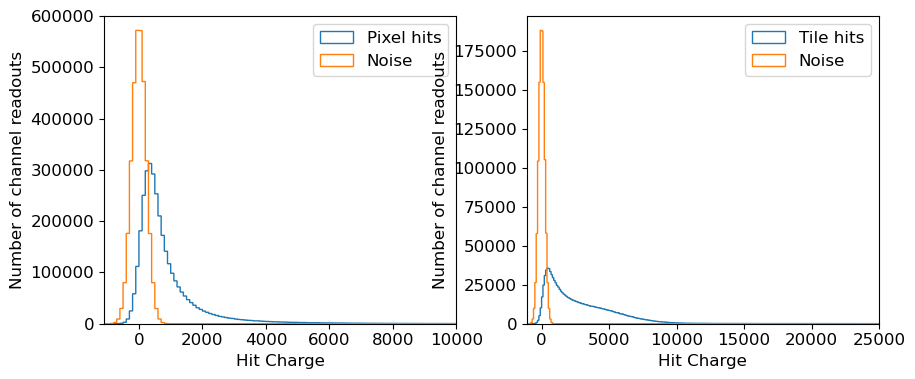

In [18]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

pBins = np.linspace(-1100, 63300, 645)
tBins = np.linspace(-1100, 155600, 1568)
fonts = 12

ax[0].hist(dP['charge'], bins = pBins, histtype = 'step', label = 'Pixel hits')
ax[0].hist(noisePixelWaveform, bins= pBins, histtype = 'step', label = 'Noise')
ax[0].set_xlim([-1100, 10000])
ax[1].hist(dT['charge'], bins = tBins, histtype = 'step', label = 'Tile hits')
ax[1].hist(noiseTileWaveform, bins= tBins, histtype = 'step', label = 'Noise')
ax[1].set_xlim([-1100, 25000])

for i in range(2):
    ax[i].set_xlabel('Hit Charge', fontsize = fonts)
    ax[i].set_ylabel('Number of channel readouts', fontsize = fonts)
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].legend(fontsize = fonts)

In [19]:
dP['waveform'].apply(min).min(), dP['waveform'].apply(max).max(), dT['waveform'].apply(min).min(), dT['waveform'].apply(max).max()

(-286.9834289550781, 52104.13671875, -275.0282897949219, 57460.02734375)

In [23]:
tWF = np.vstack(dT['waveform'].to_numpy()).ravel()
pWF = np.vstack(dP['waveform'].to_numpy()).ravel()
noiseT = noiseTileTick.ravel()
noiseP = noisePixelTick.ravel()

Hit charge per pixel/tile per sampling tick

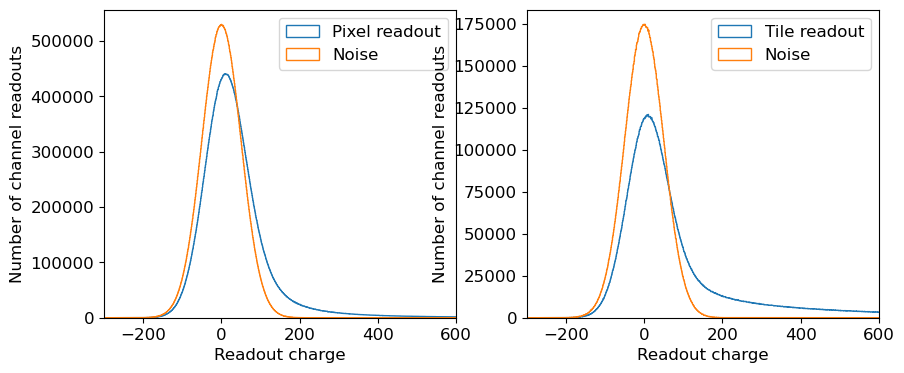

In [26]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

pBins = np.linspace(-300, 52200, 52501)
tBins = np.linspace(-300, 57500, 57801)
fonts = 12

ax[0].hist(pWF, bins = pBins, histtype = 'step', label = 'Pixel readout')
ax[0].hist(noiseP, bins= pBins, histtype = 'step', label = 'Noise')
ax[0].set_xlim([-300, 600])
ax[1].hist(tWF, bins = tBins, histtype = 'step', label = 'Tile readout')
ax[1].hist(noiseT, bins= tBins, histtype = 'step', label = 'Noise')
ax[1].set_xlim([-300, 600])

for i in range(2):
    ax[i].set_xlabel('Readout charge', fontsize = fonts)
    ax[i].set_ylabel('Number of channel readouts', fontsize = fonts)
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].legend(fontsize = fonts)


In [27]:
# number of tiles with hit charge < 50, 150, 250
(dT['charge']<50.).sum(), (dT['charge']<150.).sum(), (dT['charge']<250.).sum()

(np.int64(26366), np.int64(47397), np.int64(75529))

For each charge in the coarse tile, find the corresponding charge in the pixels (by the x-y location and time),
sum over the charge in the corresponding pixels:

In [28]:
# --- Prep (keep only needed cols to reduce memory) ---
dP2 = dP.reset_index(drop = True).copy()
dT2 = dT.reset_index(drop = True).copy()

dP2["pixel_id"] = dP2.index
dT2["tile_id"]  = dT2.index

# If you have event id, keep it; otherwise remove those lines below
need_cols_p = ["pixel_id", "event id", "trig t", "pixel x", "pixel y", "charge"]
need_cols_t = ["tile_id",  "event id", "trig t", "tile x",  "tile y", "charge"]
dP2 = dP2[need_cols_p]
dT2 = dT2[need_cols_t]

# Sort dP for searchsorted by time (within each event id works best; see approach 2 if many events)
# If you only have ONE event, just sort by "hit t".
dP2 = dP2.sort_values(["event id", "trig t"]).reset_index(drop = True)

# We'll process per event id to keep time search correct and candidate sizes small
matches_parts = []
sum_parts = []

for ev, t_ev in dT2.groupby("event id", sort = False):
    p_ev = dP2[dP2["event id"] == ev]
    if p_ev.empty:
        continue

    tP = p_ev["trig t"].to_numpy()
    # For each tile, get [t, t+10]
    tT = t_ev["trig t"].to_numpy()

    left  = np.searchsorted(tP, tT, side = "left")
    right = np.searchsorted(tP, tT + 10, side = "right")

    # Iterate tiles in this event; slices are only the time-window subset
    # (If this is still slow, we can optimize further, but it won’t blow memory.)
    for (tile_id, trig_t, tx, ty), l, r in zip(
        t_ev[["tile_id", "trig t", "tile x", "tile y"]].itertuples(index = False, name = None),
        left,
        right,
    ):
        if l >= r:
            continue

        sub = p_ev.iloc[l:r]

        m = (
            (sub["pixel x"] > tx - 5) & (sub["pixel x"] < tx + 5) &
            (sub["pixel y"] > ty - 5) & (sub["pixel y"] < ty + 5)
        )
        if not m.any():
            continue

        subm = sub.loc[m, ["pixel_id", "trig t", "pixel x", "pixel y", "charge"]].copy()
        subm["tile_id"] = tile_id

        matches_parts.append(subm[["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]])
        sum_parts.append((tile_id, float(subm["charge"].sum())))

# Build outputs
matches = pd.concat(matches_parts, ignore_index = True) if matches_parts else pd.DataFrame(
    columns=["tile_id", "pixel_id", "trig t", "pixel x", "pixel y"]
)

charge_sum = pd.DataFrame(sum_parts, columns = ["tile_id", "charge_sum"]).groupby("tile_id", as_index = False)["charge_sum"].sum()

# Add the sum onto every matching row (and/or onto dC)
matches = matches.merge(charge_sum, on = "tile_id", how = "left")
dT2 = dT2.merge(charge_sum, on = "tile_id", how = "left")
dT2["charge_sum"] = dT2["charge_sum"].fillna(0)

# If you want to write back:
dT["charge_sum"] = dT2.sort_values("tile_id")["charge_sum"].to_numpy()

In [29]:
dT

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label,charge,charge_sum
0,0,0,-1065.0,-575.0,929.386963,5804.554199,"[71.76718139648438, 62.810279846191406, 113.80...","[[0.48086702823638916, 0.5191329121589661, 0.0...","[8158, 8157, -9999]",1386.506609,15.948111
1,0,0,-1065.0,-545.0,1020.091187,6371.054199,"[-32.999149322509766, -88.00483703613281, 9.21...","[[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8102, -9999, -9999]",304.031366,0.000000
2,0,0,-1065.0,-535.0,1021.131958,6377.554199,"[-34.37238311767578, 84.75414276123047, 24.533...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8100, 8099, -9999]",966.326665,405.021456
3,0,0,-1055.0,-575.0,-568.794189,-3552.445801,"[94.542724609375, 43.767486572265625, -48.5439...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]",480.919051,0.000000
4,0,0,-1055.0,-575.0,-506.269928,-3161.945801,"[44.93190002441406, 221.96304321289062, 4.0670...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, ...","[5814, 7192, 7191]",126.962569,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]",344.125580,473.166698
1093437,999,0,-735.0,-365.0,356.679321,2227.666748,"[586.3011474609375, 369.4231872558594, -61.994...","[[0.9081302881240845, 0.0, 0.09186971187591553...","[8830264, 8830266, 8830263]",1105.921688,628.371725
1093438,999,0,-735.0,-355.0,381.176666,2380.666748,"[40.48929977416992, 7.63347053527832, 121.1170...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.24980983...","[8833149, 8833150, 8833151]",34607.093809,33867.234197
1093439,999,0,-735.0,-355.0,385.179504,2405.666748,"[57.617530822753906, 137.14410400390625, 11.58...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8833145, 8833143, 8833146]",424.614502,4103.829427


In [42]:
dT['ratio'] = dT['charge_sum']/dT['charge']

In [43]:
dT['ratio'].min(), dT['ratio'].max(), dT['charge_sum'].min(), dT['charge_sum'].max()

(-27490.929490103073,
 23611.22965550994,
 -863.2206697463989,
 156736.85701289773)

Charge on pixels/charge on tile per tile

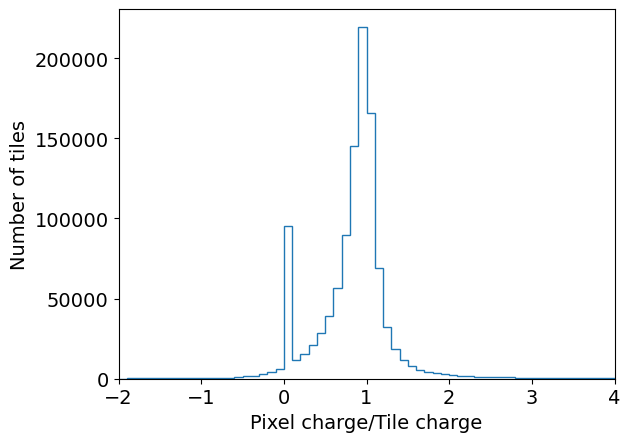

In [44]:
fig, ax = plt.subplots()

rBins = np.linspace(-2, 4, 61)
fonts = 14

ax.hist(dT['ratio'], bins = rBins, histtype = 'step')
ax.set_xlabel('Pixel charge/Tile charge', fontsize = fonts)
ax.set_ylabel('Number of tiles', fontsize = fonts)
ax.set_xlim([-2, 4])

ax.tick_params(axis = "both", labelsize = fonts)

1. why are there tiles with the ratio > 1?  It is consistent with Boxun's study with his clustering algorithm.  Now looking into more details...
2. why is there a peak at ratio = 0?

In [34]:
len(dT)

1093441

Fraction of the tiles with the pixel charge/tile charge > 1

In [45]:
(dT['ratio'] > 1).sum()

np.int64(344916)

In [46]:
344916/1093441

0.3154408879857258

Fraction of the tiles with the pixel charge = 0

In [47]:
(dT['ratio'] == 0).sum()

np.int64(86651)

In [48]:
86651/1093441

0.07924615960074663

In [49]:
dT[dT.ratio>1]

,event id,tile tpc,tile x,tile y,trig z,trig t,waveform,attribution,label,charge,charge_sum,ratio
6,0,0,-1055.0,-565.0,-506.430023,-3162.945801,"[60.37152099609375, 73.86231994628906, 25.9683...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[5812, 5817, 5811]",645.466084,681.642529,1.056047
8,0,0,-1055.0,-495.0,528.863281,3303.054199,"[30.9046630859375, 112.68680572509766, 141.279...","[[0.0, 1.0, 0.0], [0.6282956004142761, 0.37170...","[5058, 5057, 5056]",206.192841,258.786415,1.255070
10,0,0,-1055.0,-475.0,528.463013,3300.554199,"[2149.397216796875, 10244.8525390625, 342.4272...","[[0.970794141292572, 0.029205767437815666, 0.0...","[5063, 5064, -9999]",12670.613630,12986.299948,1.024915
12,0,0,-1045.0,-575.0,-502.267090,-3136.945801,"[13.283573150634766, 158.96578979492188, 73.92...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[5815, -9999, -9999]",177.926958,277.310788,1.558565
13,0,0,-1045.0,-565.0,534.147034,3336.054199,"[55.076744079589844, 66.82622528076172, 90.083...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[9350, 8916, 8162]",3145.416681,3635.882096,1.155930
...,...,...,...,...,...,...,...,...,...,...,...,...
1093433,999,0,-735.0,-485.0,-497.525726,-3107.333252,"[49.02643585205078, 592.4232177734375, 641.787...","[[0.6495320200920105, 0.3504679799079895, 0.0]...","[8828755, 8828754, 8828757]",1283.297315,1366.036788,1.064474
1093434,999,0,-735.0,-485.0,-490.800964,-3065.333252,"[42.241600036621094, -1.107519268989563, -45.4...","[[0.0, 1.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8828761, 8828760, 8828763]",751.876325,4810.885618,6.398507
1093435,999,0,-735.0,-485.0,-489.199829,-3055.333252,"[2286.964111328125, 803.978271484375, 33.20779...","[[0.9999997019767761, 0.0, 0.0], [1.0000001192...","[8828761, 8828763, 8828760]",3129.311161,3525.621504,1.126645
1093436,999,0,-735.0,-475.0,-491.921753,-3072.333252,"[96.73655700683594, -19.9937686920166, -91.338...","[[0.0, 1.0, 0.0], [0.0, 1.0, 0.0], [1.0, 0.0, ...","[8828759, 8828758, -9999]",344.125580,473.166698,1.374983


Look at the segment causing one example where the ratio > 1

In [50]:
s_0_5815 = dS[(dS.event_id==0)&(dS.segment_id==5815)]
s_0_5815

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
5815,0,1428,1428,5815,-3.668561,6555,6555,0.0,-3.668934,310.575745,...,0.0,63.936401,0.0,0.028538,0.0,0.0,-570.894348,310.575745,-3.668748,0.0


the waveform on a single pixel

In [78]:
wf_0_5815 = np.stack(dP[(dP['event id']==0)&(dP['label'].str[0]==5815)]['waveform'].to_numpy())[0]
wf_0_5815

array([128.37228394,  61.93101501, -18.10428047,  -5.18595934,
        21.63487816,  -4.18864107,  44.61186981,  56.59396744,
       -11.92835236, -64.08218384, -46.81267548,  83.74263763,
         0.52355945, -50.98975372,  31.30791473, 118.12178802,
         5.66896772,  19.68484497, -75.15161896, -18.43947411])

All the pixels/samples with the same segment

In [52]:
dP[(dP['event id']==0)&(dP['label'].str[0]==5815)]

,event id,pixel tpc,pixel x,pixel y,trig z,trig t,waveform,attribution,label,charge
13,0,0,-1049.75,-570.75,-502.26709,-3136.945801,"[128.37228393554688, 61.93101501464844, -18.10...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[5815, -9999, -9999]",277.310788


In [64]:
attri_0_5815 = dP[(dP['event id']==0)&(dP['label'].str[0]==5815)].attribution.iloc[0]
firsts = [x[0] for x in attri_0_5815]  
firsts

[1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

Ended up that the segment is landing in a single pixel \
Sum over the samples with the segment energy deposition, vs the samples without

In [79]:
wf_0_5815[:3].sum(), wf_0_5815[3:].sum()

(np.float64(172.19901847839355), np.float64(105.11176908016205))